In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

print("All imports successful")

All imports successful


In [2]:
# load augmented dataset
df = pd.read_csv('../data/guideseq_augmented.csv')
print(f"Loaded: {df.shape}")

# DNA base encoding
BASE_TO_IDX = {'A': 0, 'T': 1, 'G': 2, 'C': 3}

def one_hot_base(base):
    encoding = [0, 0, 0, 0]
    idx = BASE_TO_IDX.get(base.upper(), 0)
    encoding[idx] = 1
    return encoding

def encode_pair(guide, dna):
    guide = guide.upper()
    dna = dna.upper()
    
    features = []
    for g, d in zip(guide, dna):
        # one-hot guide base (4 features)
        guide_enc = one_hot_base(g)
        # one-hot dna base (4 features)
        dna_enc = one_hot_base(d)
        # mismatch indicator (1 feature)
        mismatch = [1 if g != d else 0]
        # combine — 9 features per position
        features.append(guide_enc + dna_enc + mismatch)
    
    return np.array(features, dtype=np.float32)

# test on first sample
sample = df.iloc[0]
encoded = encode_pair(sample['guide_seq'], sample['dna_seq'])

print(f"\nEncoded shape: {encoded.shape}")
print(f"(20 positions × 9 features)")
print(f"\nFirst position encoding:")
print(f"  Guide base: {sample['guide_seq'][0]}")
print(f"  DNA base:   {sample['dna_seq'][0]}")
print(f"  Features:   {encoded[0]}")
print(f"  Meaning: [guide_A guide_T guide_G guide_C | "
      f"dna_A dna_T dna_G dna_C | mismatch]")

Loaded: (378, 6)

Encoded shape: (20, 9)
(20 positions × 9 features)

First position encoding:
  Guide base: G
  DNA base:   G
  Features:   [0. 0. 1. 0. 0. 0. 1. 0. 0.]
  Meaning: [guide_A guide_T guide_G guide_C | dna_A dna_T dna_G dna_C | mismatch]


X shape: (378, 20, 9)
y shape: (378,)
X dtype: float32


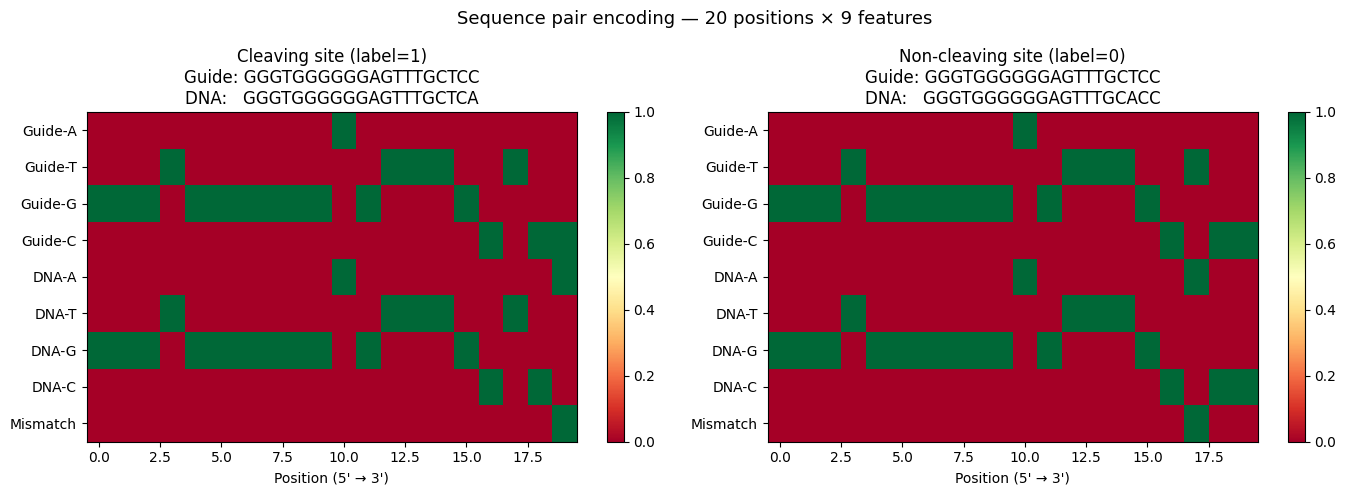


Saved X_encoded.npy and y_labels.npy


In [3]:
# encode all samples
X = np.array([encode_pair(row['guide_seq'], row['dna_seq'])
              for _, row in df.iterrows()])
y = df['label'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X dtype: {X.dtype}")

# visualize encoding of one cleaving vs one non-cleaving sample
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, title in [
    (axes[0], 1, 'Cleaving site (label=1)'),
    (axes[1], 0, 'Non-cleaving site (label=0)')
]:
    sample = df[df['label'] == label].iloc[2]
    encoded = encode_pair(sample['guide_seq'], sample['dna_seq'])
    
    im = ax.imshow(encoded.T, cmap='RdYlGn', aspect='auto',
                   vmin=0, vmax=1)
    ax.set_yticks(range(9))
    ax.set_yticklabels(['Guide-A', 'Guide-T', 'Guide-G', 'Guide-C',
                        'DNA-A', 'DNA-T', 'DNA-G', 'DNA-C',
                        'Mismatch'])
    ax.set_xlabel('Position (5\' → 3\')')
    ax.set_title(f'{title}\n'
                 f'Guide: {sample["guide_seq"]}\n'
                 f'DNA:   {sample["dna_seq"]}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Sequence pair encoding — 20 positions × 9 features',
             fontsize=13)
plt.tight_layout()
plt.show()

# save encoded data
np.save('../data/X_encoded.npy', X)
np.save('../data/y_labels.npy', y)
print("\nSaved X_encoded.npy and y_labels.npy")